## Edge signed graph problem

## Formulation

Let $G = (V,E,s)$ be a signed graph where $k \in \mathbb{N}$ and $1 \leq k \leq n$.

An edge $e \in E$ is called negative if $s(e) = −1$ and positive if $s(e) = +1$. 

Let $E^{-}$ and $E^{+}$ denote, respectively, the sets of negative and positive edges in a signed graph.

Let $K$ the sets of partition.

For a vertex set $S \subseteq V$ , let $E[S] = \{ (u,v) \in E \ | \ u,v \in S \}$ denote the subset of edges induced by $S$.

Let $S_i$ the partition $i$ of the $G$ where $i \in K = \{ 1,2, \ldots, k \}$.

A signed graph $G=(V,E,s)$ is $k$-balanced if $V$ can be partitioned into $S_1, S_2 , \ldots , S_l$ , with $l \leq k$, where $\cup_{i=1}^{l} E[S_i] = E^{+}$.

$
x_{vi} = 
\begin{cases}
1, & \text{ if } v \in S_i, \; \forall v \in V,\forall i \in K \\ 
0, & \text{otherwise}. 
\end{cases} 
$

$
y_{uv} = 
\begin{cases}
1, & \text{ if } (u,v) \text{ is removed}, \; \forall (u,v) \in E \\
0, & \text{ otherwise.} 
\end{cases} 
$

$$
\begin{align}
\min \quad & \sum\limits_{uv \in E} y_{uv} & \\
\text{s.t} \quad & \sum_{i \in [k]} x_{vi} \geq 1 & \forall v \in V  \\
& x_{ui} + x_{vi} \leq 1 + y_{uv} & \forall uv \in E^{-}, \forall i \in K \\
& x_{ui} \geq x_{vi} - y_{uv} & \forall uv \in E^{+}, \forall i \in K \\
& x_{vi} \geq x_{ui} - y_{uv} & \forall uv \in E^{+}, \forall i \in K \\
& x_{vi} \in \{0,1\} & \forall v \in V, \forall i \in K \\
& y_{vu} \in \{0,1\} & \forall uv \in E 
\end{align}
$$

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import gurobipy as gp
from collections import defaultdict

In [117]:
# defines a set with positive edges and another with negative edges
def edgesEN(G):
    EP = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] > 0]
    EN = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] < 0]

    return EP, EN

In [3]:
# define tuple (vertice,partition)
def setVK(G,k):
    nodes = G.nodes()
    vk = []
    for u in nodes:
        for v in range(k):
            a = (u,v)
            vk.append(a)

    return vk

In [4]:
def read_instance(instance):
    with open(instance, 'r') as file: 
        lines = file.readlines()

    lines = [a.strip() for a in lines]

    values = lines[0].split()
    n, m = int(values[0]), int(values[1])

    #print("n =", n)
    #print("m =", m)

    G = nx.Graph()

    for u in range(n):
        G.add_node(u)

    for e in range(1,m+1):
        values = lines[e].split()
        u, v, val = int(values[0]), int(values[1]), int(values[2])
        G.add_edge(u, v, weight=val)

    return G


In [5]:
def plotGraph(G, pos):
    plt.figure(figsize=(25, 20))
    nx.draw_networkx(G,pos,with_labels=True)
    labels = nx.get_edge_attributes(G,'weight')
    nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)

    plt.show()

In [75]:
def position(G):
    #seed = 20532
    pos = nx.spring_layout(G)
    #pos=nx.random_layout(G)
    #pos=nx.circular_layout(G)
    #pos=nx.spectral_layout(G)
    #pos=nx.spiral_layout(G)
    #pos = nx.spring_layout(G, seed=seed)

    return pos

In [76]:
def edge1_formulation(G, k, VK, EP, EN, method):

    nodes = G.nodes()
    edges = G.edges()
    K = range(k)
    
    #method = "mip" # mip or lp

    #modelnx.draw_networkx_edge_labels(G,pos,edge_labels=labels)
    model = gp.Model()

    # silent/verbose mode
    #model.Params.OutputFlag = 0

    # variables
    if method == "mip":
        y = model.addVars(edges, vtype=gp.GRB.BINARY, name="y")
        #y = model.addVars(edges, lb=0.0, ub=1.0, vtype=gp.GRB.CONTINUOUS, name="y")
        x = model.addVars(VK, vtype=gp.GRB.BINARY, name="x")

    model.update()

    #objective function
    obj = 0
    for e in edges:
        obj += y[e]
         
    model.setObjective(obj, gp.GRB.MINIMIZE)

    # constraints

    #x[(16,1)] == 1
 
    for v in nodes:
        constr = 0
        for i in K:
            constr += x[(v,i)] 
        model.addConstr(constr == 1.0, "constr2")

    for e in EN:
        for i in K:
            model.addConstr(x[(e[0],i)] + x[(e[1],i)] <= 1 + y[(e[0],e[1])], "constr3")

    for e in EP:
        for i in K:
            model.addConstr(x[(e[0],i)] >= x[(e[1],i)] - y[(e[0],e[1])], "constr4")

    for e in EP:
        for i in K:
            model.addConstr(x[(e[1],i)] >= x[(e[0],i)] - y[(e[0],e[1])], "constr5")

    if method != "mip":
        for v in model.getVars():
            v.setAttr('vtype', 'C')

    

    #model.write("edge_model.lp")

    # parameters 
    model.setParam(gp.GRB.Param.TimeLimit,3600.0)
    model.setParam(gp.GRB.Param.MIPGap,1.e-6)
    model.setParam(gp.GRB.Param.Threads,1)
    model.setParam(gp.GRB.Param.Cuts,0)
    # Global cut aggressiveness setting. 
    # Use value 0 to shut off cuts, 
    # 1 for moderate cut generation, 
    # 2 for aggressive cut generation, 
    # and 3 for very aggressive cut generation. 
    # The default -1 value chooses automatically.
    model.setParam(gp.GRB.Param.Presolve,0)
    # Controls the presolve level. 
    # A value of -1 corresponds to an automatic setting. 
    # Other options are off (0), 
    # conservative (1), 
    # or aggressive (2). 
    # More aggressive application of presolve takes more time, 
    # but can sometimes lead to a significantly tighter model.
    model.setParam(gp.GRB.Param.BranchDir,1)
    # default 0
    # -1 will always explore the down branch first, 
    # 1 will always explore the up branch first.
    

    model.optimize()
         
    tmp = 0
    if model.status == gp.GRB.OPTIMAL:
        tmp = 1
 
    objval = model.objVal
    runtime = model.Runtime
    status = tmp
    if method == "mip":
        objbound = model.objBound
        mipgap = model.MIPGap
        nodecount = model.NodeCount

    xval = {}
    for v in VK:
        xval[v] = x[v].x

    yval = {}
    for e in edges:
        yval[e] = y[e].x

    Ex = []
    for key, value in xval.items():
        if value > 0.5:
            Ex.append(key)

    Ey = []
    for key, value in yval.items():
        if value > 0.5:
            Ey.append(key)

    model.dispose()

    return objval, objbound, mipgap, nodecount, runtime, status, Ex, Ey

In [77]:
def graph_ex():
    G = nx.Graph()
    #G.add_nodes_from([1,2,3,4,5,6])
    edges = [(1,2,+1), (1,4,-1), (2,3,-1), (2,4,-1), (2,5,-1), (2,6,+1), (3,5,+1), (3,6,-1), (4,5,+1), (5,6,-1)]
    G.add_weighted_edges_from(edges)

    return G

In [78]:
def plot_graph_ex(G):
    #nx.draw_planar(G, with_labels = "True")
    pos = {1:(0,0), 2:(2,0), 3:(4,0), 4:(0,-1), 5:(2,-1), 6:(4,-1)}
    nx.draw(G, pos, with_labels="True")
    edge_labels = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(G, pos, edge_labels)
    plt.show()

In [79]:
n_=60
k_=3 # number of partition
pos_=30
neg_=5
err_=20
id_=1

#random_n20_k2_pos30_neg5_err5_1
#random_n20_k2_pos30_neg5_err5_2
#random_n20_k2_pos30_neg5_err5_3
#random_n20_k2_pos30_neg5_err5_4
#random_n20_k2_pos30_neg5_err5_5

#random_n60_k2_pos30_neg5_err5_1
#random_n60_k2_pos30_neg5_err5_2
#random_n60_k2_pos30_neg5_err5_3
#random_n60_k2_pos30_neg5_err5_4
#random_n60_k2_pos30_neg5_err5_5

# random_n60_k3_pos30_neg5_err5_1

# random_n60_k4_pos30_neg5_err5_1

# random_n60_k5_pos30_neg5_err5_1

instance = f"../data/kmbs/RANDOM/random_n{n_}_k{k_}_pos{pos_}_neg{neg_}_err{err_}_{id_}.g"
G = read_instance(instance)

#G = graph_ex()

n = G.number_of_nodes()
m = G.number_of_edges()

print("n =", n)
print("m =", m)

n = 60
m = 236


In [109]:
dict_degree = dict(G.degree())
maxkey = max(dict_degree, key=dict_degree.get)
maxvalue = max(dict_degree.values())
print(f"key: {maxkey}, value: {maxvalue}")

key: 52, value: 15


In [110]:
dict_degree = dict(G.degree())
v_e_degree = {k: v for k, v in sorted(dict_degree.items(), key=lambda item: item[1],reverse=True)}
print(v_e_degree)

list_vdegree = []
for s in v_e_degree:
    list_vdegree.append(s)

print(list_vdegree)

{52: 15, 12: 13, 28: 13, 30: 13, 44: 12, 39: 11, 42: 11, 49: 11, 8: 10, 9: 10, 37: 10, 55: 10, 6: 9, 13: 9, 20: 9, 26: 9, 33: 9, 34: 9, 51: 9, 54: 9, 58: 9, 2: 8, 3: 8, 10: 8, 11: 8, 14: 8, 16: 8, 17: 8, 21: 8, 27: 8, 57: 8, 59: 8, 0: 7, 1: 7, 4: 7, 7: 7, 19: 7, 23: 7, 25: 7, 29: 7, 36: 7, 38: 7, 40: 7, 41: 7, 45: 7, 50: 7, 5: 6, 15: 6, 18: 6, 22: 6, 43: 6, 53: 6, 31: 5, 35: 5, 48: 5, 24: 4, 32: 3, 47: 3, 56: 3, 46: 2}
[52, 12, 28, 30, 44, 39, 42, 49, 8, 9, 37, 55, 6, 13, 20, 26, 33, 34, 51, 54, 58, 2, 3, 10, 11, 14, 16, 17, 21, 27, 57, 59, 0, 1, 4, 7, 19, 23, 25, 29, 36, 38, 40, 41, 45, 50, 5, 15, 18, 22, 43, 53, 31, 35, 48, 24, 32, 47, 56, 46]


In [118]:
def define_partition(data_dict):
    """
    Groups keys in a dictionary by their shared values.

    Args:
        data_dict (dict): The input dictionary.

    Returns:
        defaultdict: A dictionary where keys are the original values,
                     and values are lists of keys that share that value.
    """
    value_to_keys = defaultdict(list)
    for key, value in data_dict.items():
        value_to_keys[value].append(key)
    return value_to_keys

In [119]:
keys_grouped_by_value = define_partition(v_e_degree)

partition = {}
for value, keys in keys_grouped_by_value.items():
    partition[value] = keys

print(partition)

{15: [52], 13: [12, 28, 30], 12: [44], 11: [39, 42, 49], 10: [8, 9, 37, 55], 9: [6, 13, 20, 26, 33, 34, 51, 54, 58], 8: [2, 3, 10, 11, 14, 16, 17, 21, 27, 57, 59], 7: [0, 1, 4, 7, 19, 23, 25, 29, 36, 38, 40, 41, 45, 50], 6: [5, 15, 18, 22, 43, 53], 5: [31, 35, 48], 4: [24], 3: [32, 47, 56], 2: [46]}


In [120]:
K = [] 
for i in partition.keys():
    K.append(i)
print(K)

[15, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2]


In [121]:
while len(list_vdegree) > 0:
    list_vdegree.pop(0)

print(list_vdegree)

[]


In [122]:
[c for c in nx.find_cliques(G)] # Returns all maximal cliques in an undirected graph.

[[2, 35, 38, 14],
 [2, 11],
 [2, 12, 44],
 [2, 44, 59],
 [2, 47, 59],
 [3, 27, 12],
 [3, 55, 51],
 [3, 30, 9],
 [3, 30, 51],
 [3, 30, 12],
 [3, 30, 15],
 [3, 39],
 [5, 35],
 [5, 11, 50],
 [5, 47],
 [5, 53],
 [5, 56],
 [6, 39, 33],
 [6, 39, 57],
 [6, 20],
 [6, 21, 9],
 [6, 57, 12],
 [6, 30, 33],
 [6, 30, 12],
 [6, 30, 54],
 [6, 30, 9],
 [7, 24],
 [7, 42],
 [7, 26, 28],
 [7, 13, 16, 37],
 [7, 13, 28],
 [8, 4],
 [8, 36],
 [8, 12, 24],
 [8, 12, 44],
 [8, 14, 20],
 [8, 50],
 [8, 53],
 [8, 56, 44],
 [9, 40],
 [9, 42, 21],
 [9, 42, 30],
 [9, 45, 21],
 [9, 19, 30],
 [9, 29],
 [9, 31],
 [11, 17, 29],
 [11, 57],
 [11, 30],
 [11, 23, 50],
 [11, 23, 29],
 [13, 16, 1],
 [13, 17],
 [13, 19, 1],
 [13, 19, 10],
 [13, 19, 28],
 [13, 19, 55],
 [14, 33, 26],
 [14, 20, 26],
 [14, 20, 35, 38],
 [14, 25],
 [15, 24],
 [15, 34, 37],
 [15, 42, 30],
 [16, 40],
 [16, 44, 29],
 [16, 31, 37],
 [17, 42],
 [17, 20, 26],
 [17, 53, 41],
 [17, 53, 26],
 [18, 36, 39],
 [18, 12, 30],
 [18, 50],
 [18, 58],
 [20, 27],
 [20

In [123]:
max(nx.find_cliques(G), key=len)  # The largest maximal clique in G

[52, 34, 28, 43, 4]

In [124]:
sum(1 for c in nx.find_cliques(G))  # The number of maximal cliques in G

137

In [125]:
max(len(c) for c in nx.find_cliques(G)) # The size of the largest maximal clique = clique number of the graph

5

In [126]:
[c for c in nx.enumerate_all_cliques(G)] # Returns all cliques in an undirected graph

[[0],
 [1],
 [2],
 [3],
 [4],
 [5],
 [6],
 [7],
 [8],
 [9],
 [10],
 [11],
 [12],
 [13],
 [14],
 [15],
 [16],
 [17],
 [18],
 [19],
 [20],
 [21],
 [22],
 [23],
 [24],
 [25],
 [26],
 [27],
 [28],
 [29],
 [30],
 [31],
 [32],
 [33],
 [34],
 [35],
 [36],
 [37],
 [38],
 [39],
 [40],
 [41],
 [42],
 [43],
 [44],
 [45],
 [46],
 [47],
 [48],
 [49],
 [50],
 [51],
 [52],
 [53],
 [54],
 [55],
 [56],
 [57],
 [58],
 [59],
 [0, 27],
 [0, 30],
 [0, 33],
 [0, 39],
 [0, 51],
 [0, 52],
 [0, 54],
 [1, 13],
 [1, 16],
 [1, 19],
 [1, 22],
 [1, 25],
 [1, 49],
 [1, 52],
 [2, 11],
 [2, 12],
 [2, 14],
 [2, 35],
 [2, 38],
 [2, 44],
 [2, 47],
 [2, 59],
 [3, 9],
 [3, 12],
 [3, 15],
 [3, 27],
 [3, 30],
 [3, 39],
 [3, 51],
 [3, 55],
 [4, 8],
 [4, 25],
 [4, 28],
 [4, 34],
 [4, 43],
 [4, 46],
 [4, 52],
 [5, 11],
 [5, 35],
 [5, 47],
 [5, 50],
 [5, 53],
 [5, 56],
 [6, 9],
 [6, 12],
 [6, 20],
 [6, 21],
 [6, 30],
 [6, 33],
 [6, 39],
 [6, 54],
 [6, 57],
 [7, 13],
 [7, 16],
 [7, 24],
 [7, 26],
 [7, 28],
 [7, 37],
 [7, 42],
 [8

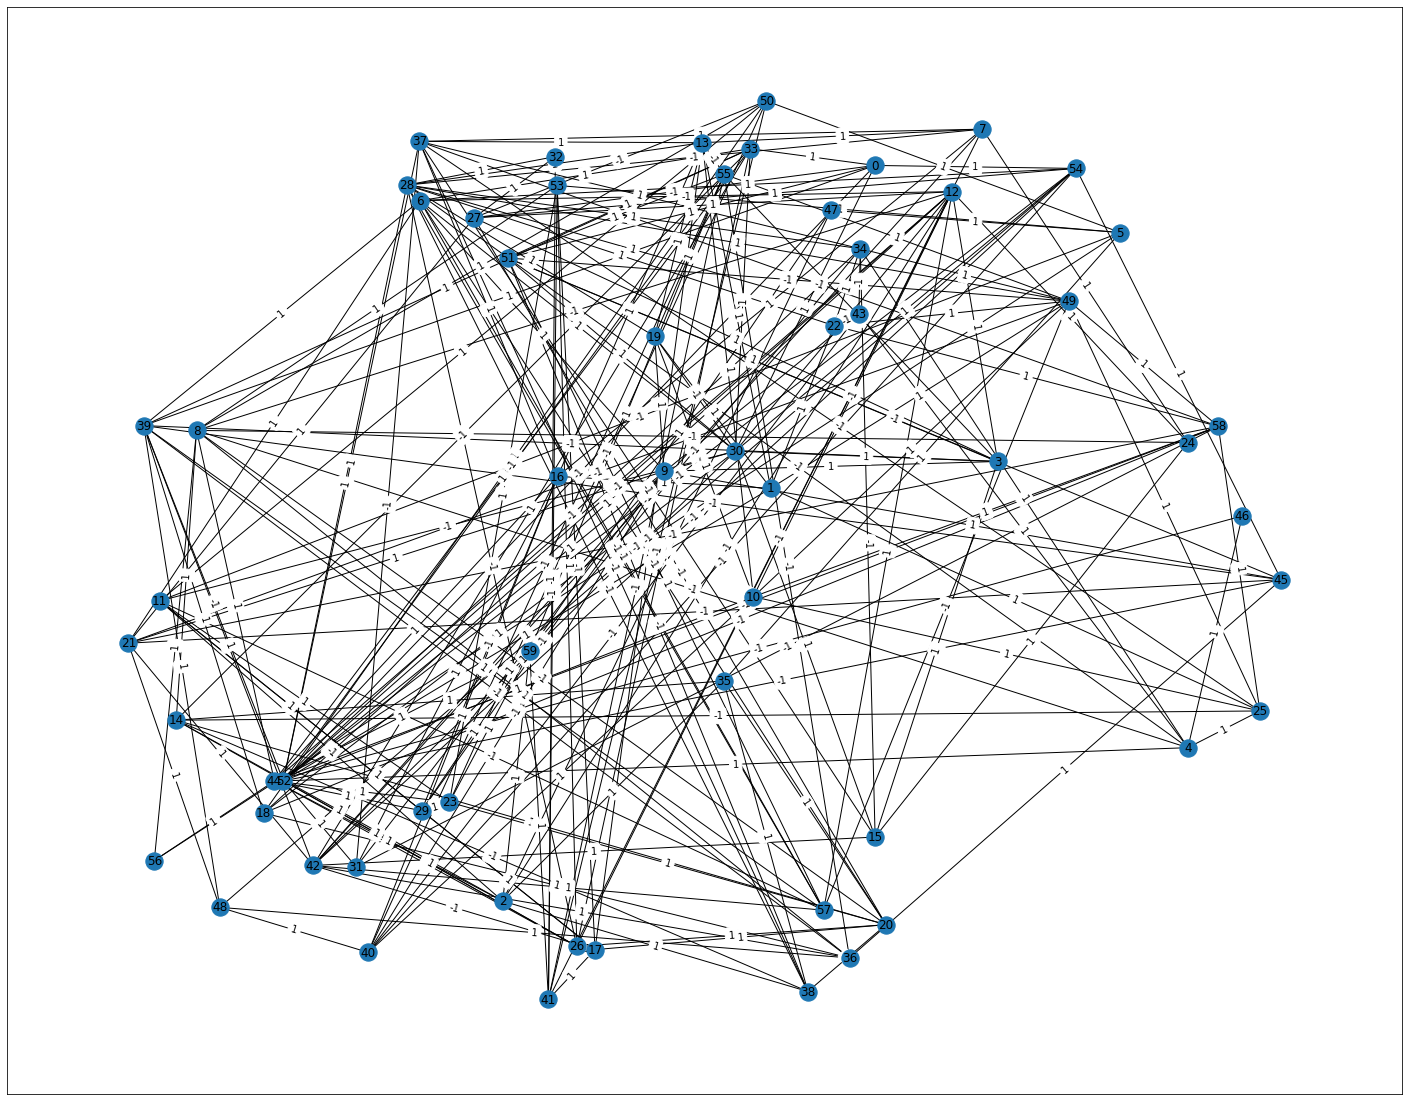

In [127]:
pos = position(G)
plotGraph(G,pos)

In [128]:
EP, EN = edgesEN(G)
HP = nx.Graph()
HN = nx.Graph()

HP.add_nodes_from(G)
HN.add_nodes_from(G)

HP.add_edges_from(EP)
HN.add_edges_from(EN)

print(f"G : #nodes= {G.number_of_nodes()}, #edges = {G.number_of_edges()}")
print(f"HP : #nodes= {HP.number_of_nodes()}, #edges = {HP.number_of_edges()}")
print(f"HN : #nodes= {HN.number_of_nodes()}, #edges = {HN.number_of_edges()}")

G : #nodes= 60, #edges = 236
HP : #nodes= 60, #edges = 150
HN : #nodes= 60, #edges = 86


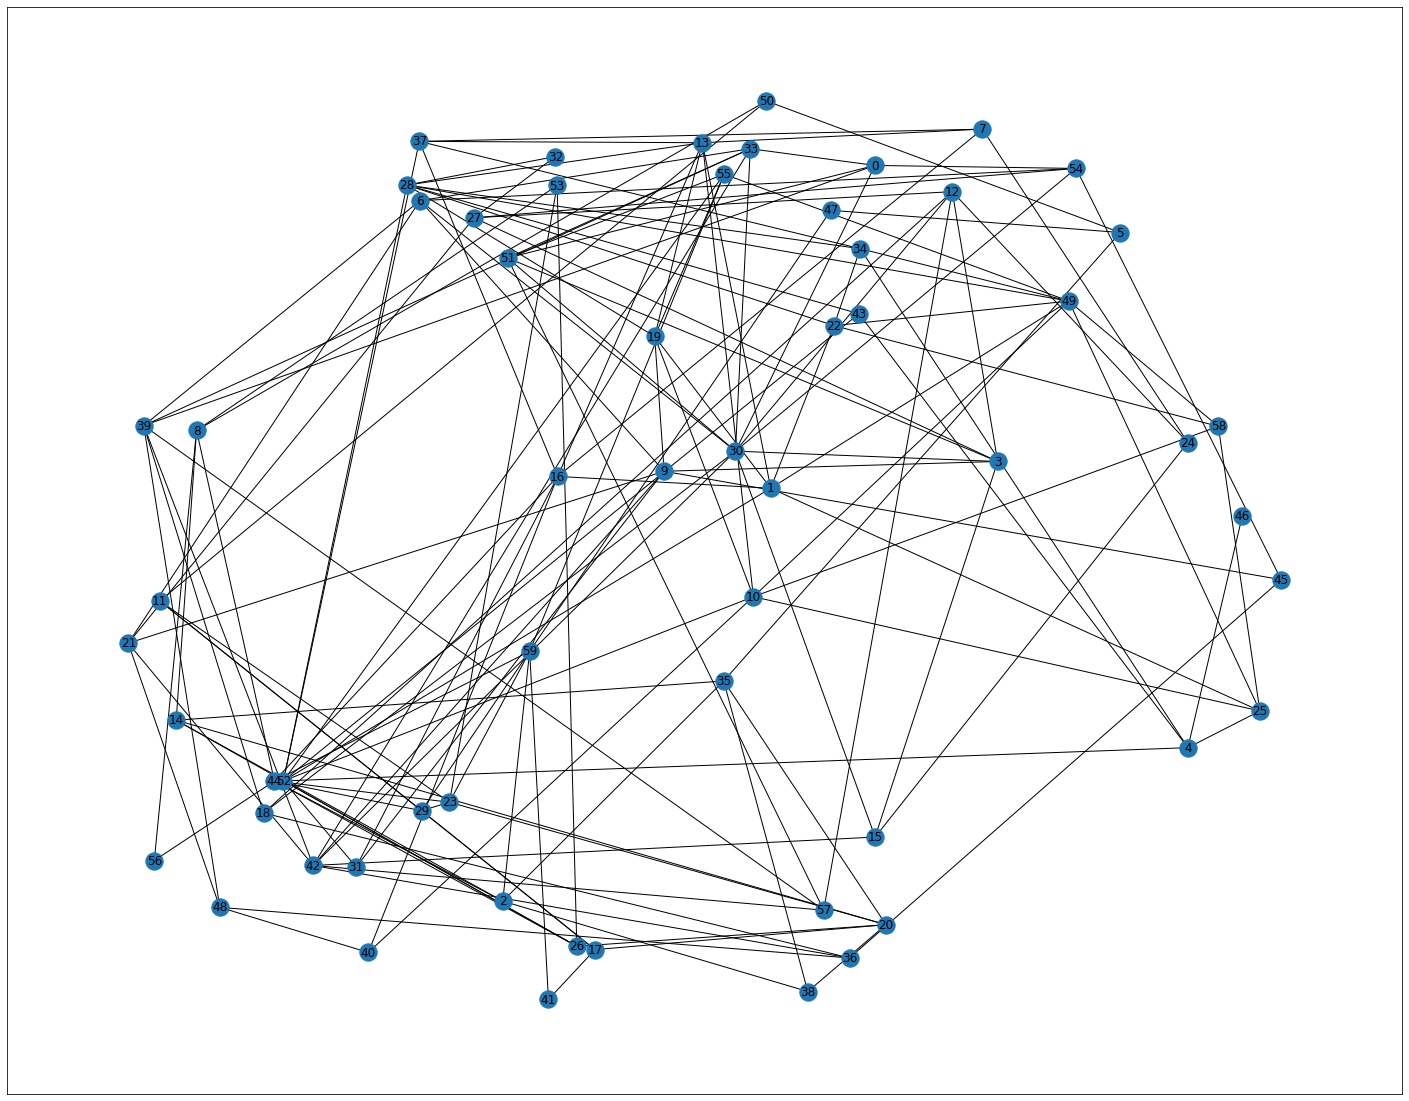

In [129]:
plotGraph(HP, pos)

In [140]:
dict_degree_pos = dict(HP.degree())

maxkey = max(dict_degree_pos, key=dict_degree_pos.get)
maxvalue = max(dict_degree_pos.values())
print(f"max key: {maxkey}, max value: {maxvalue}")

v_e_degree_pos = {k: v for k, v in sorted(dict_degree_pos.items(), key=lambda item: item[1],reverse=True)}
print(v_e_degree_pos)

list_vdegree_pos = []
for s in v_e_degree_pos:
    #print(s)
    list_vdegree_pos.append(s)

print(list_vdegree_pos)

max key: 30, max value: 10
{30: 10, 52: 9, 28: 8, 42: 8, 44: 8, 49: 8, 1: 7, 9: 7, 10: 7, 13: 7, 16: 7, 39: 7, 59: 7, 3: 6, 6: 6, 12: 6, 19: 6, 20: 6, 23: 6, 33: 6, 51: 6, 0: 5, 2: 5, 4: 5, 8: 5, 14: 5, 21: 5, 22: 5, 25: 5, 26: 5, 27: 5, 29: 5, 34: 5, 35: 5, 37: 5, 54: 5, 55: 5, 7: 4, 11: 4, 15: 4, 17: 4, 18: 4, 36: 4, 48: 4, 57: 4, 58: 4, 5: 3, 24: 3, 31: 3, 38: 3, 40: 3, 43: 3, 45: 3, 50: 3, 53: 3, 32: 2, 41: 2, 47: 2, 56: 2, 46: 1}
[30, 52, 28, 42, 44, 49, 1, 9, 10, 13, 16, 39, 59, 3, 6, 12, 19, 20, 23, 33, 51, 0, 2, 4, 8, 14, 21, 22, 25, 26, 27, 29, 34, 35, 37, 54, 55, 7, 11, 15, 17, 18, 36, 48, 57, 58, 5, 24, 31, 38, 40, 43, 45, 50, 53, 32, 41, 47, 56, 46]


In [142]:
partition_dict = define_partition(v_e_degree_pos)

partition = {}
for value, keys in partition_dict.items():
    partition[value] = keys

print(partition)

{10: [30], 9: [52], 8: [28, 42, 44, 49], 7: [1, 9, 10, 13, 16, 39, 59], 6: [3, 6, 12, 19, 20, 23, 33, 51], 5: [0, 2, 4, 8, 14, 21, 22, 25, 26, 27, 29, 34, 35, 37, 54, 55], 4: [7, 11, 15, 17, 18, 36, 48, 57, 58], 3: [5, 24, 31, 38, 40, 43, 45, 50, 53], 2: [32, 41, 47, 56], 1: [46]}


In [143]:
K =[] 
for i in partition.keys():
    K.append(i)
print(K)

[10, 9, 8, 7, 6, 5, 4, 3, 2, 1]


In [144]:
for k in K:
    print(partition[k])

[30]
[52]
[28, 42, 44, 49]
[1, 9, 10, 13, 16, 39, 59]
[3, 6, 12, 19, 20, 23, 33, 51]
[0, 2, 4, 8, 14, 21, 22, 25, 26, 27, 29, 34, 35, 37, 54, 55]
[7, 11, 15, 17, 18, 36, 48, 57, 58]
[5, 24, 31, 38, 40, 43, 45, 50, 53]
[32, 41, 47, 56]
[46]


In [147]:
clique_pos = [c for c in nx.find_cliques(HP)]
print(len(clique_pos))

for c in clique_pos:
    print(c)

94
[1, 13, 16]
[1, 13, 19]
[1, 49, 25]
[1, 49, 22]
[1, 52]
[2, 59, 44]
[2, 35, 38]
[2, 35, 14]
[4, 25]
[4, 34]
[4, 43, 52]
[4, 46]
[5, 50]
[5, 35]
[5, 47]
[7, 16, 37, 13]
[7, 24]
[8, 50]
[8, 44, 56]
[8, 53]
[8, 14]
[9, 3]
[9, 45]
[9, 19]
[9, 21, 42]
[9, 21, 6]
[9, 31]
[10, 40]
[10, 13, 19]
[10, 49, 25, 58]
[10, 52]
[11, 50]
[11, 29, 17]
[11, 29, 23]
[13, 28, 19]
[14, 20, 26]
[14, 20, 35]
[16, 40]
[16, 44]
[16, 31]
[17, 41]
[17, 20]
[19, 55]
[20, 38, 35]
[20, 23]
[21, 48]
[21, 27]
[22, 49, 34, 28]
[22, 49, 58]
[23, 44, 59, 29]
[23, 53]
[24, 12]
[24, 15]
[26, 44]
[26, 53]
[26, 52]
[27, 32]
[27, 3, 12]
[27, 54]
[28, 32]
[28, 43, 52]
[30, 33, 0, 51]
[30, 33, 42]
[30, 33, 6]
[30, 3, 51]
[30, 3, 12]
[30, 3, 15]
[30, 12, 18]
[30, 15, 42]
[30, 54, 0]
[30, 54, 6]
[31, 52]
[34, 37]
[36, 48]
[36, 18]
[36, 42]
[36, 45]
[37, 52]
[39, 48]
[39, 33, 0]
[39, 33, 42]
[39, 33, 6]
[39, 18]
[39, 57, 42]
[40, 48]
[41, 59]
[45, 54]
[47, 59]
[49, 55]
[52, 55]
[55, 51]
[55, 59]
[57, 51]
[57, 12]


In [149]:
clique_neg = [c for c in nx.find_cliques(HN)]
print(len(clique_neg))

for c in clique_neg:
    print(c)

82
[0, 27]
[0, 52]
[1]
[3, 55]
[3, 39]
[4, 8]
[4, 28]
[5, 56]
[5, 11]
[5, 53]
[7, 26, 28]
[7, 42]
[9, 40]
[9, 29]
[9, 30]
[11, 57]
[11, 2]
[11, 30]
[12, 2]
[12, 6]
[12, 8]
[12, 41]
[12, 10]
[12, 44]
[12, 52]
[13, 17]
[13, 55]
[14, 25]
[14, 38]
[14, 33]
[15, 34]
[15, 37]
[16, 29]
[17, 26]
[17, 42]
[17, 53]
[18, 50]
[18, 58]
[19, 30]
[20, 8]
[20, 27]
[20, 6]
[21, 49]
[21, 58]
[21, 45]
[22, 43]
[23, 50]
[24, 8]
[25, 37]
[26, 33]
[27, 50]
[28, 57]
[28, 38]
[31, 58, 37]
[32, 41]
[33, 44]
[34, 59]
[34, 43]
[34, 52]
[35]
[36, 8]
[36, 55]
[36, 39]
[37, 38]
[38, 51]
[39, 45, 52]
[40, 43]
[40, 54]
[40, 55]
[42, 54]
[45, 51]
[46, 44]
[47, 2]
[48, 54]
[49, 57]
[49, 51]
[50, 41]
[53, 41]
[54, 52]
[55, 41]
[57, 6]
[58, 44]


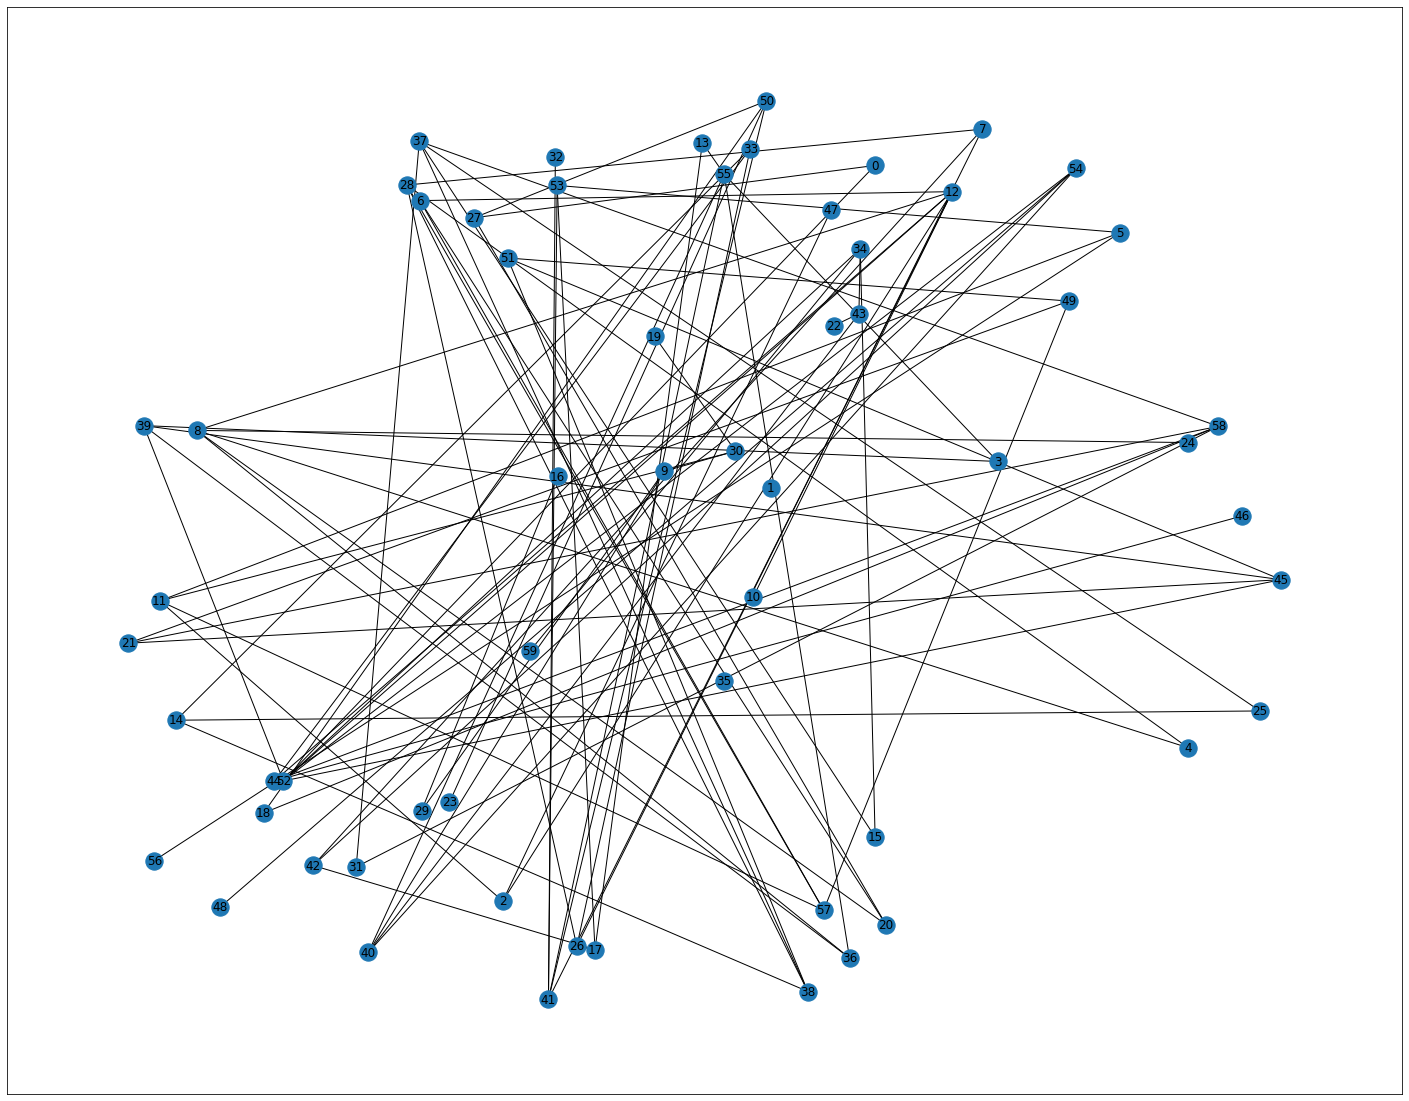

In [138]:
plotGraph(HN,pos)

In [139]:
dict_degree_neg = dict(HN.degree())

maxkey = max(dict_degree_neg, key=dict_degree_neg.get)
maxvalue = max(dict_degree_neg.values())
print(f"max key: {maxkey}, max value: {maxvalue}")

v_e_degree_neg = {k: v for k, v in sorted(dict_degree_neg.items(), key=lambda item: item[1],reverse=True)}
print(v_e_degree_neg)

list_vdegree_neg = []
for s in v_e_degree_neg:
    #print(s)
    list_vdegree_neg.append(s)

print(list_vdegree_neg)

max key: 12, max value: 7
{12: 7, 52: 6, 8: 5, 28: 5, 37: 5, 41: 5, 55: 5, 58: 5, 11: 4, 17: 4, 26: 4, 34: 4, 38: 4, 39: 4, 40: 4, 44: 4, 45: 4, 50: 4, 54: 4, 57: 4, 2: 3, 5: 3, 6: 3, 7: 3, 9: 3, 14: 3, 20: 3, 21: 3, 27: 3, 30: 3, 33: 3, 36: 3, 42: 3, 43: 3, 49: 3, 51: 3, 53: 3, 0: 2, 3: 2, 4: 2, 13: 2, 15: 2, 18: 2, 25: 2, 29: 2, 31: 2, 10: 1, 16: 1, 19: 1, 22: 1, 23: 1, 24: 1, 32: 1, 46: 1, 47: 1, 48: 1, 56: 1, 59: 1, 1: 0, 35: 0}
[12, 52, 8, 28, 37, 41, 55, 58, 11, 17, 26, 34, 38, 39, 40, 44, 45, 50, 54, 57, 2, 5, 6, 7, 9, 14, 20, 21, 27, 30, 33, 36, 42, 43, 49, 51, 53, 0, 3, 4, 13, 15, 18, 25, 29, 31, 10, 16, 19, 22, 23, 24, 32, 46, 47, 48, 56, 59, 1, 35]


In [98]:
VK = setVK(G, k_)
method = "mip"
objval, objbound, mipgap, nodecount, runtime, status, xk, yelim = edge1_formulation(G, k_, VK, EP, EN, method)

Set parameter Username
Academic license - for non-commercial use only - expires 2026-02-19
Set parameter TimeLimit to value 3600
Set parameter MIPGap to value 1e-06
Set parameter Threads to value 1
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter BranchDir to value 1
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Core(TM) i5-1035G1 CPU @ 1.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 1 threads

Non-default parameters:
TimeLimit  3600
MIPGap  1e-06
BranchDir  1
Cuts  0
Presolve  0
Threads  1

Optimize a model with 1218 rows, 416 columns and 3654 nonzeros
Model fingerprint: 0x7fc63478
Variable types: 0 continuous, 416 integer (416 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 114.000

In [99]:
print("ub = ", objval)
print("time = ", runtime)
print("status = ", status)
print("lb = ", objbound)
print("gap = ", mipgap)
print("nodes = ", nodecount)

ub =  41.0
time =  20.625289916992188
status =  1
lb =  41.0
gap =  0.0
nodes =  8752.0


In [100]:
print(xk)

[(0, 1), (1, 0), (2, 2), (3, 1), (4, 0), (5, 0), (6, 1), (7, 0), (8, 2), (9, 1), (10, 0), (11, 2), (12, 1), (13, 0), (14, 2), (15, 1), (16, 0), (17, 2), (18, 1), (19, 0), (20, 2), (21, 1), (22, 0), (23, 2), (24, 1), (25, 0), (26, 2), (27, 1), (28, 0), (29, 2), (30, 1), (31, 1), (32, 0), (33, 1), (34, 0), (35, 2), (36, 1), (37, 0), (38, 2), (39, 1), (40, 0), (41, 2), (42, 1), (43, 2), (44, 2), (45, 1), (46, 0), (47, 0), (48, 1), (49, 0), (50, 0), (51, 1), (52, 0), (53, 2), (54, 1), (55, 0), (56, 2), (57, 1), (58, 0), (59, 2)]


In [101]:
print(yelim)

[(0, 27), (2, 11), (3, 39), (4, 28), (4, 43), (5, 35), (6, 12), (6, 57), (7, 24), (7, 28), (8, 20), (8, 50), (9, 19), (9, 30), (11, 50), (13, 55), (14, 38), (16, 31), (16, 44), (17, 26), (17, 53), (21, 45), (25, 37), (26, 52), (27, 32), (28, 43), (31, 52), (34, 52), (36, 39), (37, 58), (39, 45), (40, 48), (40, 55), (41, 53), (42, 54), (43, 52), (45, 51), (47, 59), (48, 54), (51, 55), (55, 59)]


In [102]:
partition = []
for i in range(k_):
    a = []
    for v in xk:
        if v[1] == i:
            a.append(v[0])
    partition.append(set(a))
    
print("Partitions:")
for i in range(k_):
    print(f"i={i}: tam={len(partition[i])}, S[{i}]={partition[i]}")

Partitions:
i=0: tam=22, S[0]={1, 4, 5, 7, 10, 13, 16, 19, 22, 25, 28, 32, 34, 37, 40, 46, 47, 49, 50, 52, 55, 58}
i=1: tam=21, S[1]={0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 31, 33, 36, 39, 42, 45, 48, 51, 54, 57}
i=2: tam=17, S[2]={2, 35, 38, 8, 41, 11, 43, 44, 14, 17, 20, 53, 23, 56, 26, 59, 29}


In [65]:
nx.community.is_partition(G, partition)

True

In [66]:
partition_map = {}
for idx, cluster_nodes in enumerate(partition):
    for node in cluster_nodes:
        partition_map[node] = idx

#for key, value in partition_map.items():
#    print(f"{key}: {value}")

In [67]:
color_map = []
for node in G:
    if partition_map[node] == 0:
        color_map.append('gray')
    elif partition_map[node] == 1:
        color_map.append('green')
    else:
        color_map.append('yellow')

#node_colors = [partition_map[n] for n in G.nodes]

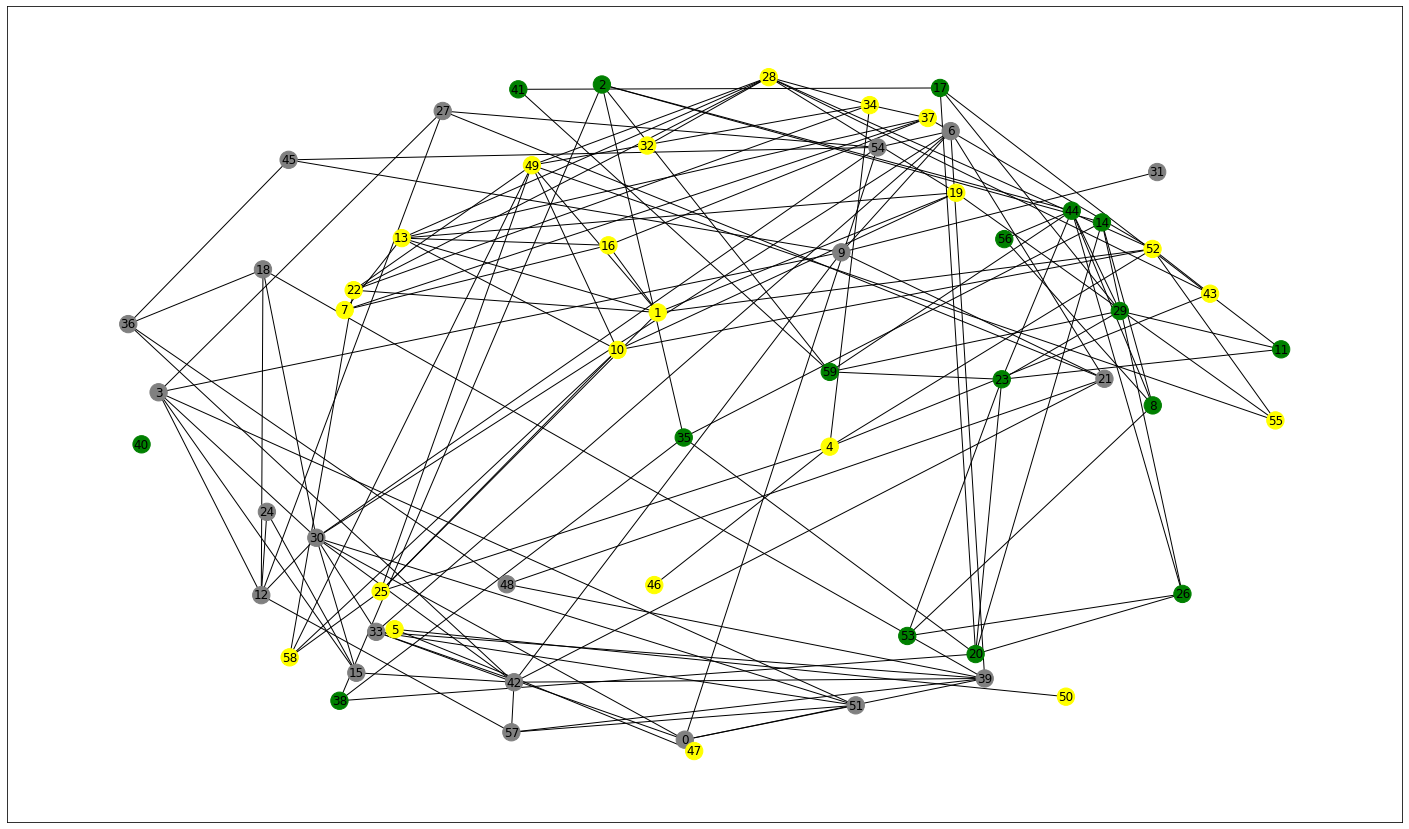

In [68]:
HP.remove_edges_from(yelim)
plt.figure(figsize=(25, 15))        
nx.draw_networkx(HP, pos, node_size=300, node_color=color_map, with_labels=True)
plt.show()

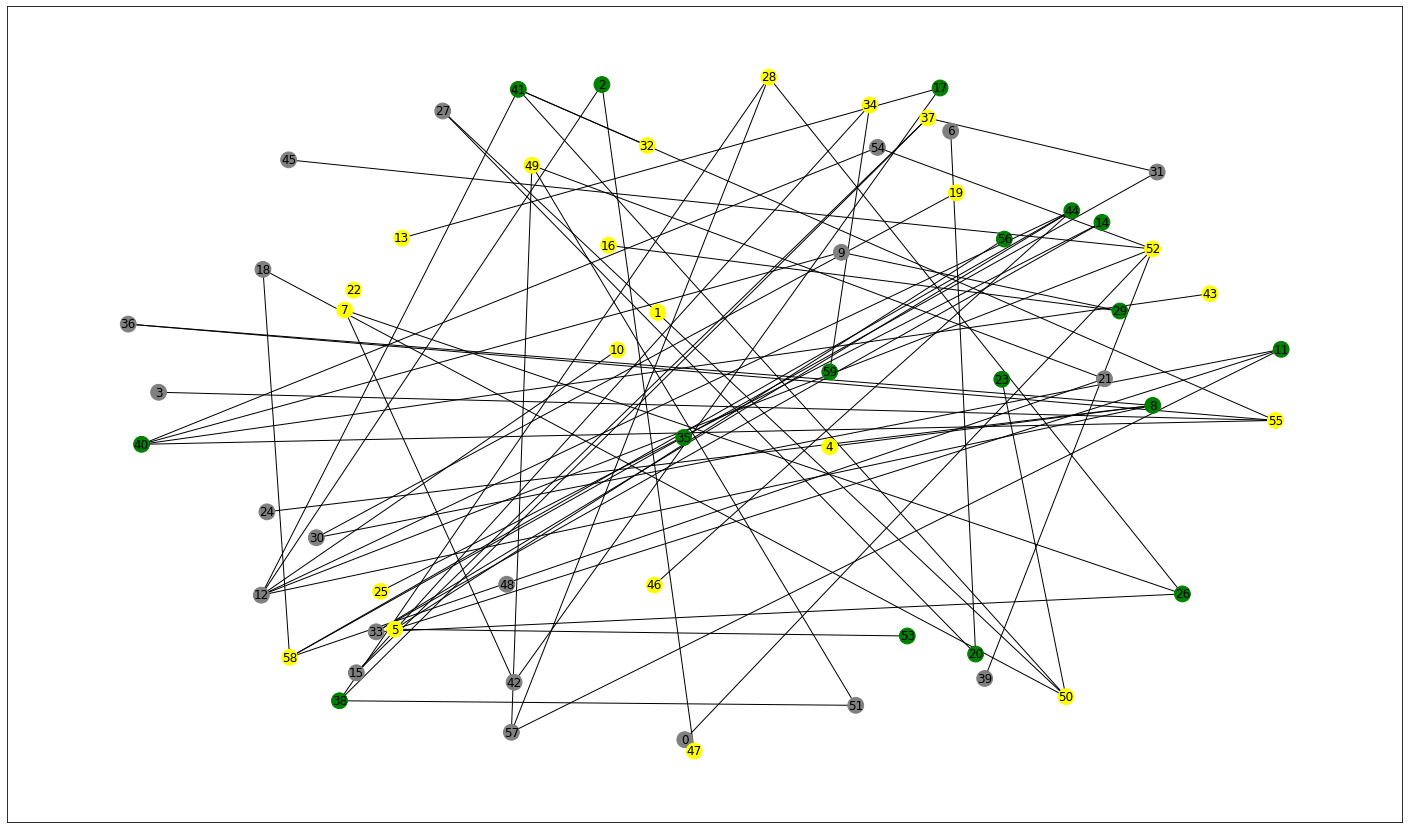

In [69]:
HN.remove_edges_from(yelim)
plt.figure(figsize=(25, 15))        
nx.draw_networkx(HN, pos, node_size=250, node_color=color_map, with_labels=True)
plt.show()

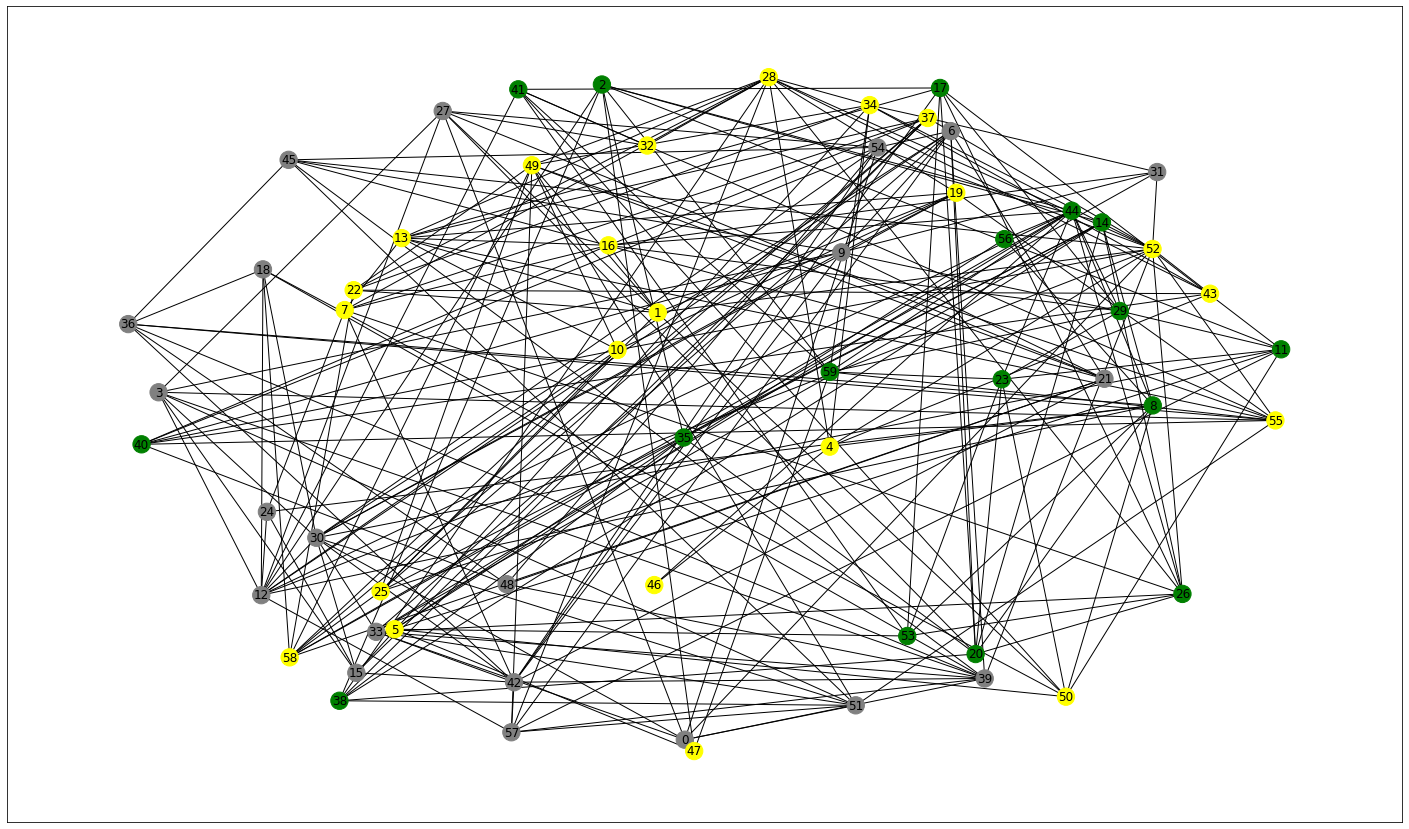

In [70]:
plt.figure(figsize=(25, 15))        
nx.draw_networkx(G, pos, node_size=300, node_color=color_map, with_labels=True)
#labels = nx.get_edge_attributes(G,'weight')
#nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)
plt.show()

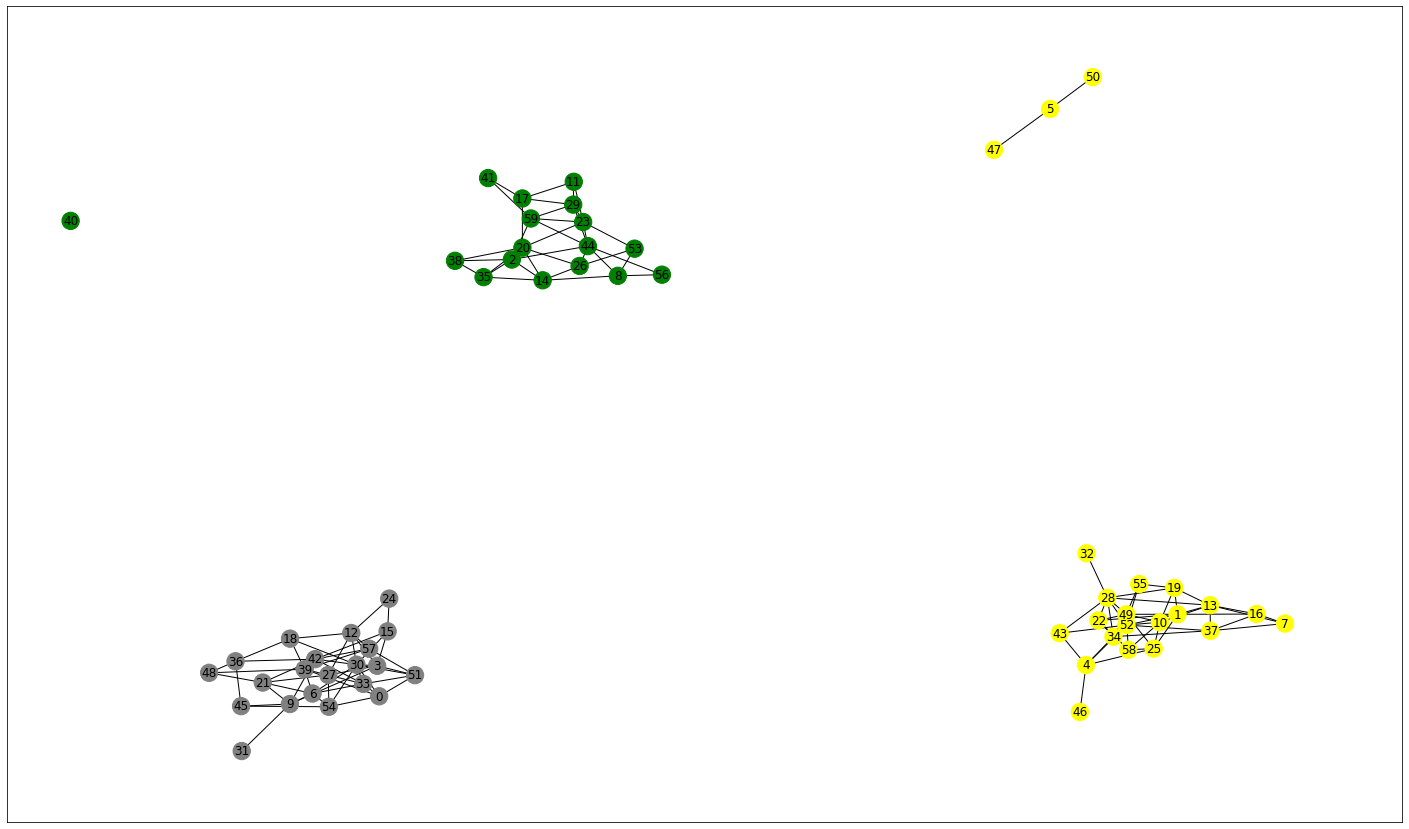

In [71]:
seed = 20532
plt.figure(figsize=(25, 15))        
pos1 = nx.spring_layout(HP, seed=seed)
nx.draw_networkx(HP, pos1, node_size=300, node_color=color_map, with_labels=True)
plt.show()